In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Employee-Attrition - Employee-Attrition.csv")

In [4]:
df.shape

(1470, 35)

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df.describe(include=['object'])

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [9]:
# Count how many zeros are present in each numeric column
zero_counts = (df == 0).sum()

# Sort columns by number of zeros (descending)
zero_counts = zero_counts.sort_values(ascending=False)

print("Zero value counts per column:")
print(zero_counts)


Zero value counts per column:
StockOptionLevel            631
YearsSinceLastPromotion     581
YearsWithCurrManager        263
YearsInCurrentRole          244
NumCompaniesWorked          197
TrainingTimesLastYear        54
YearsAtCompany               44
TotalWorkingYears            11
BusinessTravel                0
Age                           0
Attrition                     0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EmployeeNumber                0
EnvironmentSatisfaction       0
MonthlyIncome                 0
MaritalStatus                 0
JobSatisfaction               0
JobRole                       0
JobLevel                      0
JobInvolvement                0
HourlyRate                    0
Gender                        0
StandardHours                 0
RelationshipSatisfaction      0
PerformanceRating             0
PercentSal

In [10]:
# Check rows where TotalWorkingYears == 0 and YearsAtCompany == 0
valid_zero = df[(df['TotalWorkingYears'] == 0) & (df['YearsAtCompany'] == 0)]

# Count of valid zeros
print("Valid zeros:", valid_zero.shape[0])

# Check rows where TotalWorkingYears == 0 but YearsAtCompany > 0 (invalid cases)
invalid_zero = df[(df['TotalWorkingYears'] == 0) & (df['YearsAtCompany'] > 0)]

# Count of invalid zeros
print("Invalid zeros:", invalid_zero.shape[0])

# Optional: see their average age
print("Average age of invalid zeros:", invalid_zero['Age'].mean())

# Optional: view sample invalid rows
print(invalid_zero[['Age', 'YearsAtCompany', 'TotalWorkingYears']].head())


Valid zeros: 11
Invalid zeros: 0
Average age of invalid zeros: nan
Empty DataFrame
Columns: [Age, YearsAtCompany, TotalWorkingYears]
Index: []


count    11.000000
mean     19.181818
std       2.750207
min      18.000000
25%      18.000000
50%      18.000000
75%      18.500000
max      27.000000
Name: Age, dtype: float64
      Age  TotalWorkingYears
23     21                  0
127    19                  0
296    18                  0
301    18                  0
457    18                  0
615    27                  0
727    18                  0
828    18                  0
972    18                  0
1153   18                  0
1311   18                  0


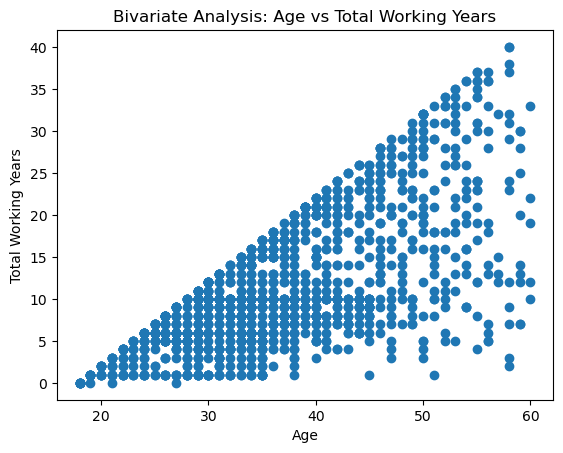

In [11]:
# Filter employees with 0 TotalWorkingYears
zero_work_exp = df[df['TotalWorkingYears'] == 0]

# View their Age values
print(zero_work_exp['Age'].describe())  # Summary stats (mean, median, min, max)

# Or to view all those rows
print(zero_work_exp[['Age', 'TotalWorkingYears']])

# Optional: visualize with a scatter plot
import matplotlib.pyplot as plt

plt.scatter(df['Age'], df['TotalWorkingYears'])
plt.xlabel('Age')
plt.ylabel('Total Working Years')
plt.title('Bivariate Analysis: Age vs Total Working Years')
plt.show()


In [12]:
df.drop_duplicates(inplace=True)
df.dropna(axis=1,how='all',inplace=True)

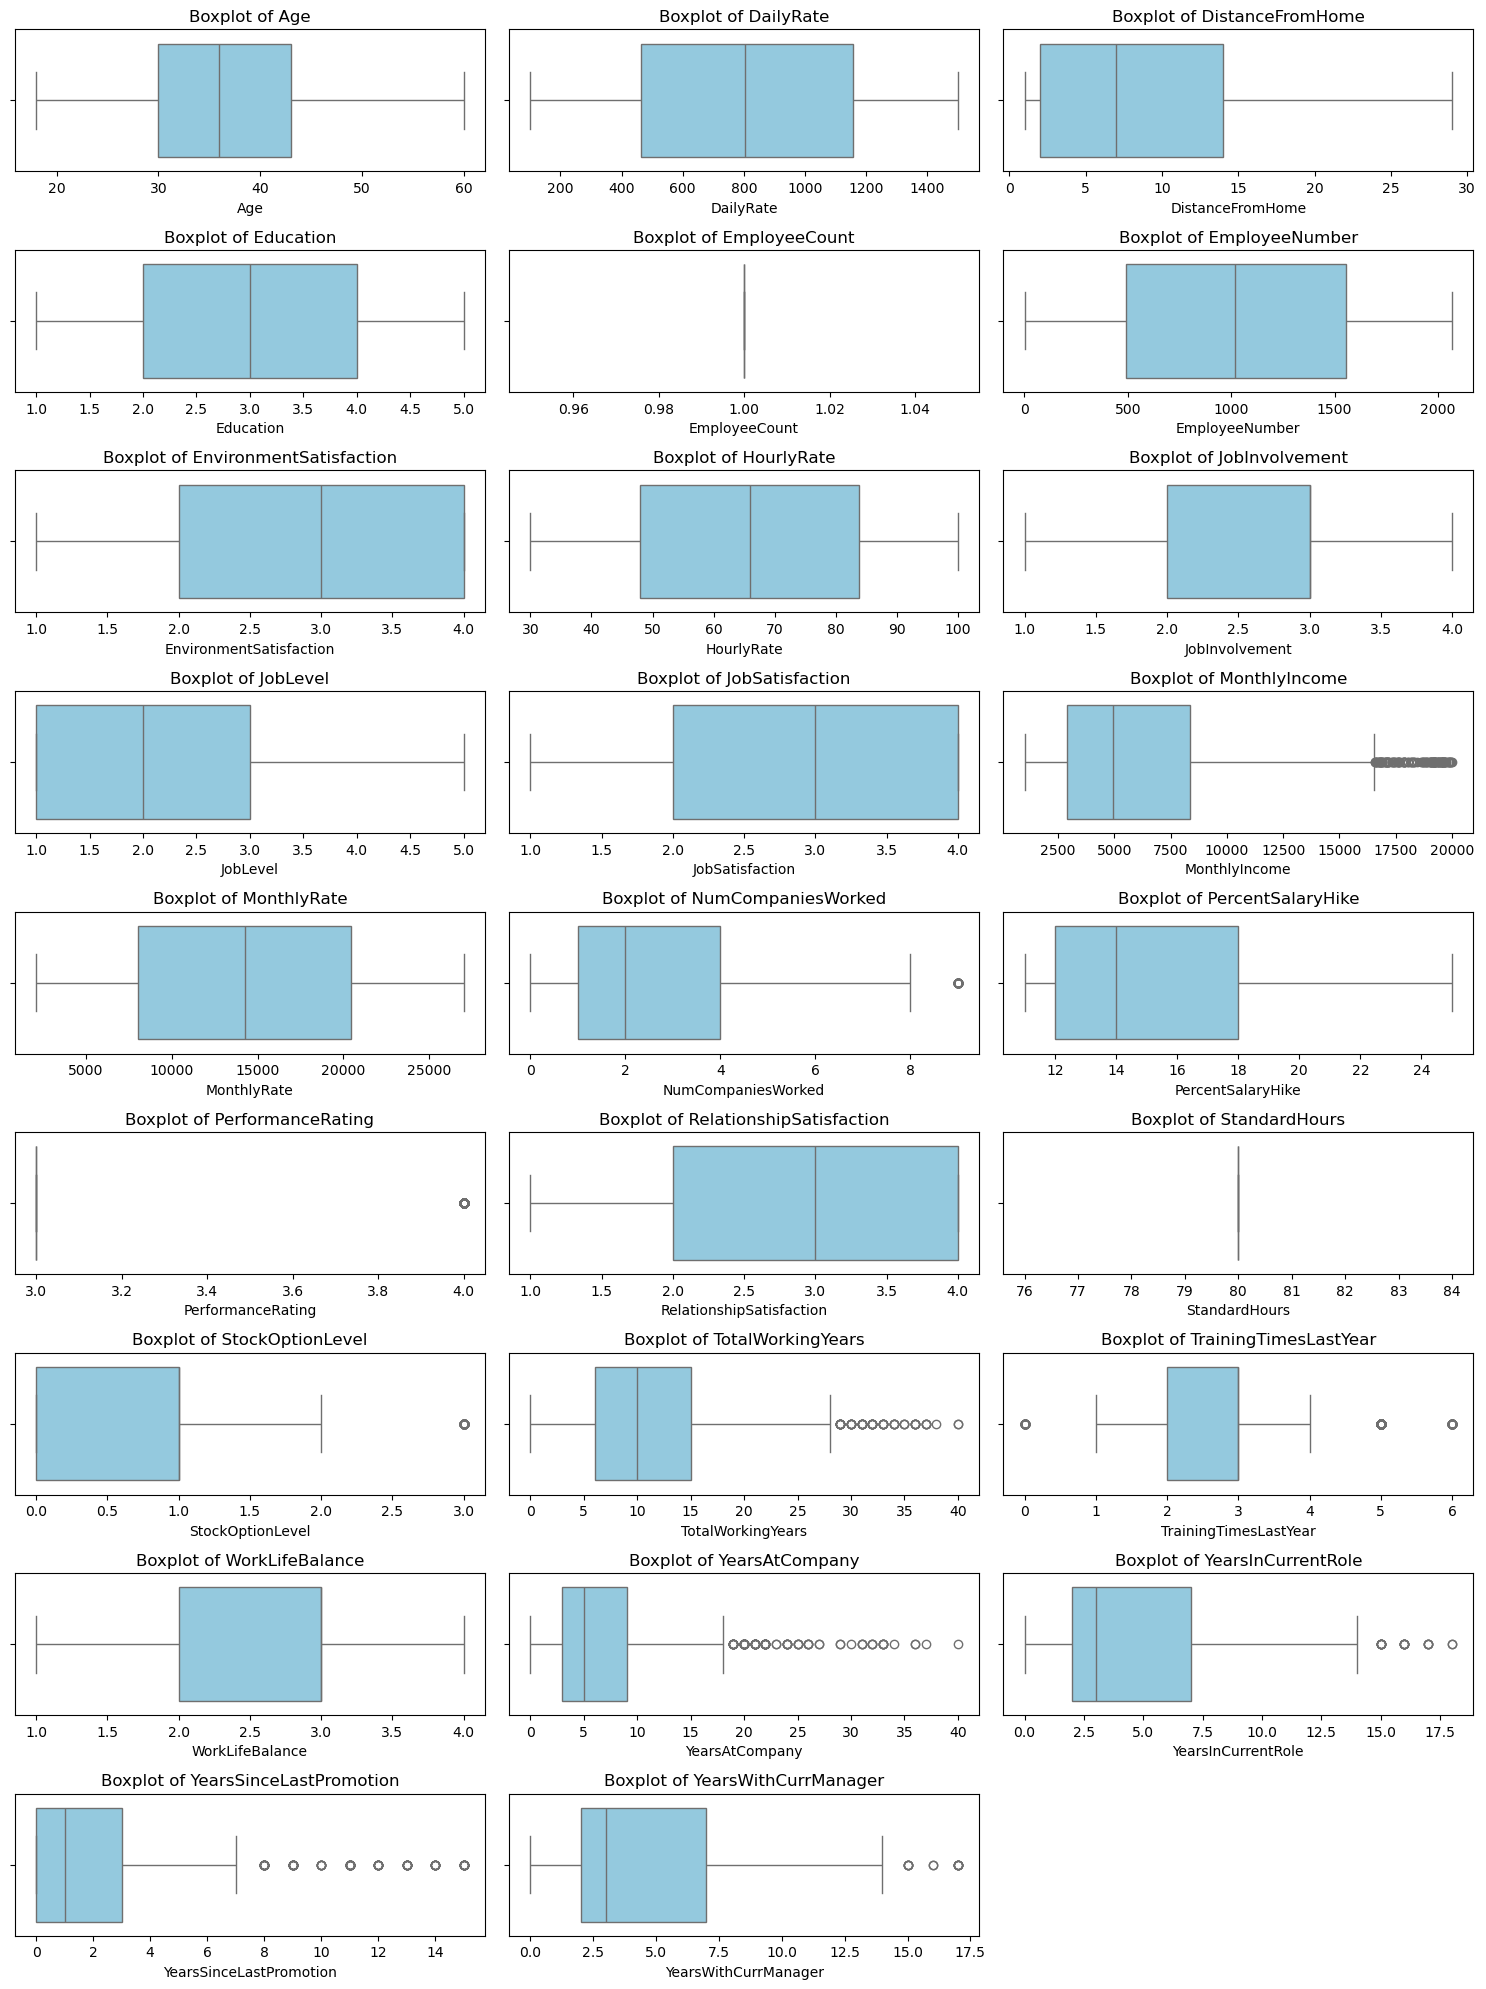

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set up the plot grid
plt.figure(figsize=(15, 20))

# Loop through numeric columns and plot boxplots
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//3 + 1, 3, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [14]:
df.drop(['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1,inplace=True)

In [16]:
from sklearn.preprocessing import LabelEncoder
le_attrition = LabelEncoder()
le_gender = LabelEncoder()
le_overtime = LabelEncoder()

df['Attrition'] = le_attrition.fit_transform(df['Attrition'])
df['Gender'] = le_gender.fit_transform(df['Gender'])
df['OverTime'] = le_overtime.fit_transform(df['OverTime'])

# One-hot encode
one_hot_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)



In [17]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False


In [18]:
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [19]:
x = df.drop('Attrition', axis=1)  # all columns except target
y = df['Attrition']               # target column


In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [21]:
#Feature selection
df.corr()['Attrition'].sort_values(ascending=False)

Attrition                            1.000000
OverTime                             0.246118
MaritalStatus_Single                 0.175419
JobRole_Sales Representative         0.157234
BusinessTravel_Travel_Frequently     0.115143
JobRole_Laboratory Technician        0.098290
Department_Sales                     0.080855
DistanceFromHome                     0.077924
EducationField_Technical Degree      0.069355
EducationField_Marketing             0.055781
NumCompaniesWorked                   0.043494
JobRole_Human Resources              0.036215
Gender                               0.029453
JobRole_Sales Executive              0.019774
MonthlyRate                          0.015170
PerformanceRating                    0.002889
JobRole_Research Scientist          -0.000360
HourlyRate                          -0.006846
PercentSalaryHike                   -0.013478
EducationField_Other                -0.017898
Education                           -0.031373
EducationField_Life Sciences      

In [22]:
from sklearn.feature_selection import chi2, SelectKBest



chi2_selector = SelectKBest(chi2, k=15)
chi2_selector.fit(x_train, y_train)
selected_features = x_train.columns[chi2_selector.get_support()]
print(selected_features)


Index(['Age', 'DailyRate', 'DistanceFromHome', 'JobLevel', 'MonthlyIncome',
       'MonthlyRate', 'OverTime', 'StockOptionLevel', 'TotalWorkingYears',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager',
       'JobRole_Laboratory Technician', 'JobRole_Sales Representative',
       'MaritalStatus_Single'],
      dtype='object')


In [24]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(x_train, y_train)
mi_series = pd.Series(mi, index=x_train.columns)
mi_series.sort_values(ascending=False).head(20)

OverTime                          0.042795
YearsAtCompany                    0.039959
MonthlyIncome                     0.036904
StockOptionLevel                  0.030228
TotalWorkingYears                 0.028092
YearsInCurrentRole                0.027194
JobLevel                          0.025767
Age                               0.025183
JobRole_Sales Executive           0.022794
MaritalStatus_Single              0.016085
JobRole_Manufacturing Director    0.015703
YearsWithCurrManager              0.013390
HourlyRate                        0.013250
JobRole_Laboratory Technician     0.010592
JobRole_Sales Representative      0.009716
DistanceFromHome                  0.009300
JobSatisfaction                   0.007965
JobRole_Research Director         0.007336
EducationField_Medical            0.007154
YearsSinceLastPromotion           0.006220
dtype: float64

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(x_train, y_train)

importances = pd.Series(rf.feature_importances_, index=x_train.columns)
importances.sort_values(ascending=False).head(20)

MonthlyIncome               0.071186
TotalWorkingYears           0.061366
Age                         0.056951
DailyRate                   0.054081
MonthlyRate                 0.048838
DistanceFromHome            0.047238
YearsAtCompany              0.046584
HourlyRate                  0.044742
YearsWithCurrManager        0.042643
OverTime                    0.042629
NumCompaniesWorked          0.039591
PercentSalaryHike           0.034468
YearsInCurrentRole          0.030448
StockOptionLevel            0.029085
JobSatisfaction             0.027309
EnvironmentSatisfaction     0.026784
YearsSinceLastPromotion     0.024425
JobLevel                    0.023839
RelationshipSatisfaction    0.021891
TrainingTimesLastYear       0.020740
dtype: float64

In [26]:
selected_features =['Age', 'DailyRate','DistanceFromHome','JobLevel','JobSatisfaction', 'MonthlyIncome', 'MonthlyRate','OverTime',
       'PercentSalaryHike','StockOptionLevel', 'TotalWorkingYears', 'YearsAtCompany',
       'YearsInCurrentRole','YearsWithCurrManager','MaritalStatus_Single']


In [27]:
x_train =x_train[selected_features]
x_test = x_test[selected_features]

In [28]:
print("X_Train columns:",x_train.columns.tolist())
print("X_Test columns:",x_test.columns.tolist())
print("Train shape:",x_train.shape)
print("Test shape:",x_test.shape)

X_Train columns: ['Age', 'DailyRate', 'DistanceFromHome', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'OverTime', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'MaritalStatus_Single']
X_Test columns: ['Age', 'DailyRate', 'DistanceFromHome', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'OverTime', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'MaritalStatus_Single']
Train shape: (1176, 15)
Test shape: (294, 15)


In [29]:
one_hot_cols = ['MaritalStatus_Single','OverTime']
ordinal_cols = ['JobLevel', 'JobSatisfaction','StockOptionLevel']

# Identify continuous numeric columns to scale
continuous_cols = [col for col in x_train.columns
                   if col not in one_hot_cols + ordinal_cols]

print("Continuous columns to scale:", continuous_cols)

# Scale only continuous features
scaler = StandardScaler()
x_train[continuous_cols] = scaler.fit_transform(x_train[continuous_cols])
x_test[continuous_cols] = scaler.transform(x_test[continuous_cols])

Continuous columns to scale: ['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']


In [30]:
scaled_summary = x_train[continuous_cols].agg(['mean', 'std']).T

print(scaled_summary.head(10))  # show first 10 columns for a quick look


                              mean       std
Age                  -4.229421e-17  1.000425
DailyRate             1.359457e-16  1.000425
DistanceFromHome     -4.682573e-17  1.000425
MonthlyIncome        -7.930164e-17  1.000425
MonthlyRate           7.552538e-18  1.000425
PercentSalaryHike    -1.480297e-16  1.000425
TotalWorkingYears    -7.288199e-17  1.000425
YearsAtCompany       -1.586033e-17  1.000425
YearsInCurrentRole    5.588878e-17  1.000425
YearsWithCurrManager  7.854639e-17  1.000425


In [34]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
smote = SMOTETomek(random_state=42)
x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)
print("Before:",y_train.value_counts())
print("After:",y_train_bal.value_counts())

Before: Attrition
0    986
1    190
Name: count, dtype: int64
After: Attrition
0    983
1    983
Name: count, dtype: int64


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [36]:
models = {
    'Logistic Regression':{
        'model':LogisticRegression(),
        'params':{}
    },
    'KNN':{
        'model':KNeighborsClassifier(),
        'params':{'n_neighbors':[3,5,9,11],'weights':['uniform','distance']}
    },

    'Decision Tree':{
        'model':DecisionTreeClassifier(),
        'params':{'max_depth':[1,2,3,4,5,6,7,8,9,10],
                  'criterion':['gini','entropy']}
    },
    
    'Random Forest':{
        'model':RandomForestClassifier(),
        'params':{'n_estimators':[10,20,30,40,50,60],
                  'criterion':['gini','entropy']}
    }
    }

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import *

results = []

for name , config in models.items():
  grid = GridSearchCV(config['model'],config['params'],cv=3,scoring='accuracy')
  grid.fit(x_train,y_train)



  y_hat = grid.predict(x_test)
  acc = accuracy_score(y_test,y_hat)
  f1 = f1_score(y_test,y_hat)
  recall = recall_score(y_test,y_hat)
  precision = precision_score(y_test,y_hat)

  results.append({
      'model':name,
      'best_params':grid.best_params_,
      'accuracy':acc,
      'f1_score':f1,
      'recall':recall,
      'precision':precision
  })

In [38]:
result_df  = pd.DataFrame(results).T
result_df

,0,1,2,3
model,Logistic Regression,KNN,Decision Tree,Random Forest
best_params,{},"{'n_neighbors': 9, 'weights': 'uniform'}","{'criterion': 'gini', 'max_depth': 4}","{'criterion': 'entropy', 'n_estimators': 20}"
accuracy,0.87415,0.833333,0.833333,0.843537
f1_score,0.372881,0.109091,0.222222,0.28125
recall,0.234043,0.06383,0.148936,0.191489
precision,0.916667,0.375,0.4375,0.529412


In [39]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=400,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=5.26,
    eval_metric='logloss'
)


xgb.fit(x_train_bal, y_train_bal)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [40]:
y_pred = xgb.predict(x_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Test Accuracy: 0.7006802721088435
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       247
           1       0.29      0.62      0.40        47

    accuracy                           0.70       294
   macro avg       0.60      0.67      0.60       294
weighted avg       0.81      0.70      0.74       294

[[177  70]
 [ 18  29]]


In [41]:
from sklearn.linear_model import LogisticRegression #classification model

lr = LogisticRegression()
lr.fit(x_train, y_train)


LogisticRegression()

In [42]:
y_pred = lr.predict(x_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Test Accuracy: 0.8741496598639455
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       247
           1       0.92      0.23      0.37        47

    accuracy                           0.87       294
   macro avg       0.89      0.61      0.65       294
weighted avg       0.88      0.87      0.84       294

[[246   1]
 [ 36  11]]


In [43]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_random = RandomizedSearchCV(
    rf, param_distributions=param_dist,
    n_iter=50, cv=5, scoring='accuracy',
    n_jobs=-1, random_state=42
)

rf_random.fit(x_train, y_train)

print("Best Params:", rf_random.best_params_)
print("Best Accuracy:", rf_random.best_score_)

Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5, 'bootstrap': True}
Best Accuracy: 0.860544536602957


In [45]:
rf = RandomForestClassifier(
    n_estimators=100,
    min_samples_split= 2,
    max_depth=5,
    class_weight='balanced_subsample',
    min_samples_leaf= 4,
    bootstrap=True,
    max_features='sqrt',
    random_state=42


)
rf.fit(x_train_bal, y_train_bal)


RandomForestClassifier(class_weight='balanced_subsample', max_depth=5,
                       min_samples_leaf=4, random_state=42)

In [46]:
y_pred = rf.predict(x_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.7414965986394558
              precision    recall  f1-score   support

           0       0.91      0.77      0.83       247
           1       0.33      0.57      0.42        47

    accuracy                           0.74       294
   macro avg       0.62      0.67      0.62       294
weighted avg       0.81      0.74      0.77       294

[[191  56]
 [ 20  27]]


In [47]:
y_pred_proba = rf.predict_proba(x_test)[:,1]

# try threshold = 0.6 or 0.7
y_pred = (y_pred_proba >= 0.4).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.66      0.77       247
           1       0.29      0.72      0.41        47

    accuracy                           0.67       294
   macro avg       0.61      0.69      0.59       294
weighted avg       0.82      0.67      0.71       294

[[162  85]
 [ 13  34]]
